In [1]:
%load_ext autoreload
%autoreload 2
from backend.processing.visualization import *
from backend.database.city_io import *

In [ ]:
conn = connect_db()
net = get_or_create_city(conn, "Madrid")

1


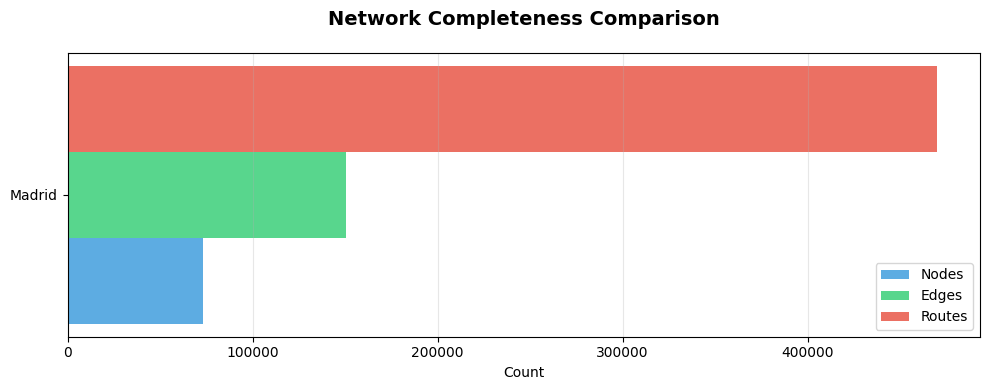

🔄 Building graph for city ID 1...


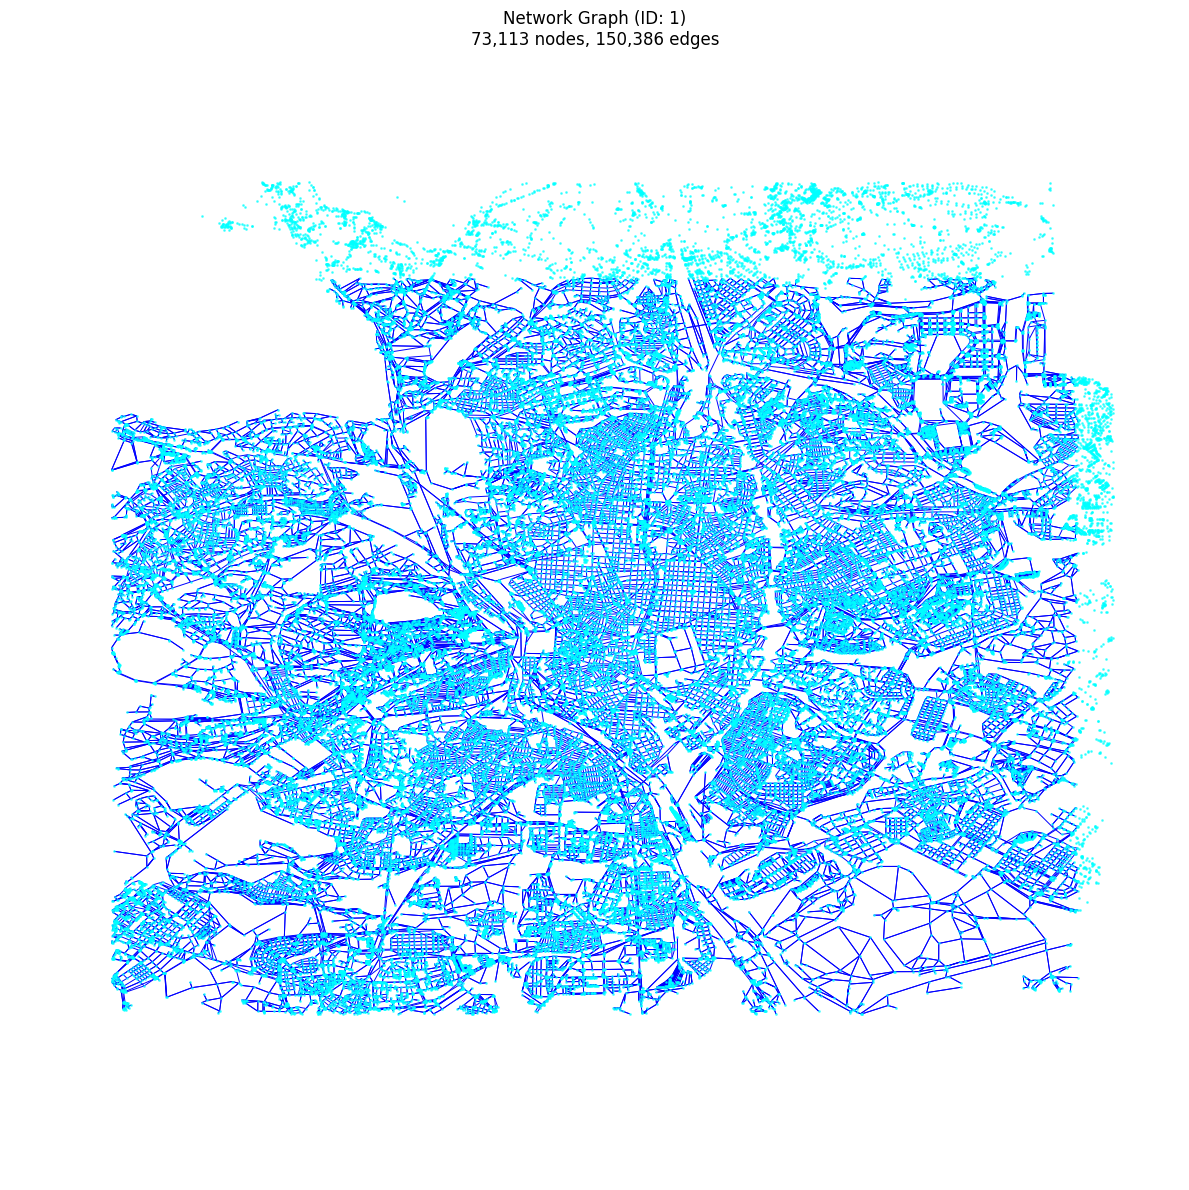

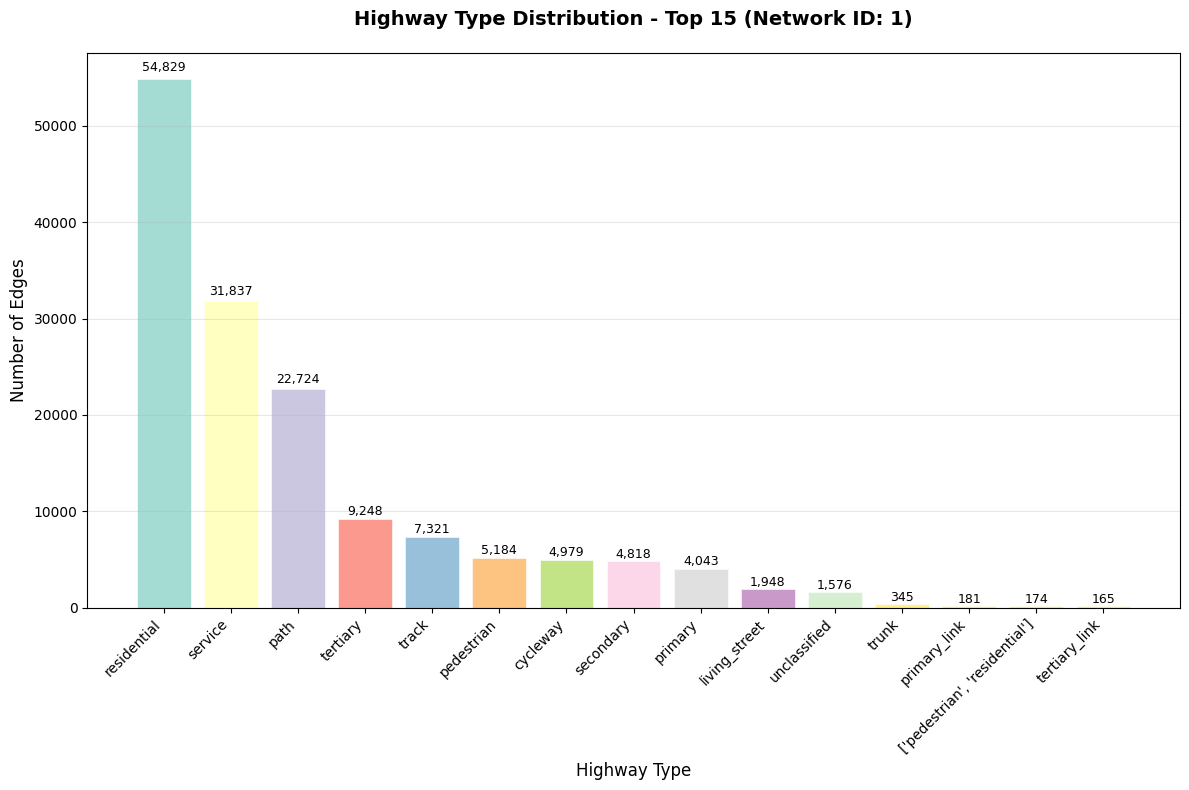

NETWORK STATISTICS

🏙️  Madrid (ID: 1)
   📊 Nodes: 73,113
   📊 Edges: 150,386
   📊 Routes: 469,675
   🌍 Bounds: 40.326830°N to 40.530009°N, -3.821694°E to -3.576996°E
   🚴 Avg trip duration: 21.7 minutes
   🚴 Trip duration range: 0.0 - 41795.6 minutes
   🚴 Unique bikes: 3,625



In [9]:
# Plot overview of all cities
plot_network_overview(conn)

# Plot the city graph for the current city
plot_network_graph(conn, net)

# Plot the distribution of highway types for the current city
plot_highway_distribution(conn, net)

# Print detailed statistics about all cities
print_network_stats(conn)



🎨 Testing Feature Visualization System

1. Features Overview Plot
------------------------------
🔄 Generating features overview for city 1...


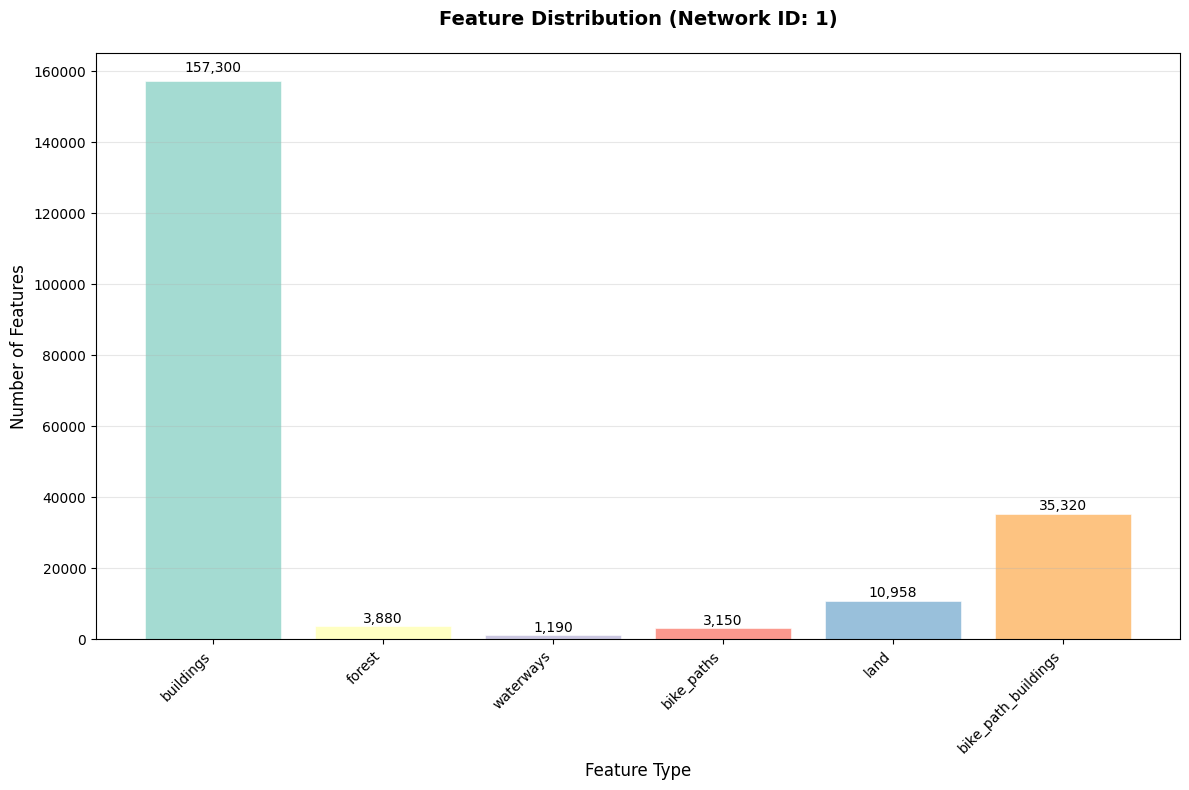

   Using Madrid center: (40.440087, -3.695152)

2. Main Features Map
------------------------------
🎨 Generating features map for city 1...
   Center: (40.440087, -3.695152)
   Boundary: 4000m x 3000m at 0° rotation
🔄 Loading features from database for city 1...
   ✔ buildings: 4839 features
   ✔ waterways: 25 features
   ✔ forest: 41 features
   ✔ bike_paths: 56 features
   ✔ land: 90 features
   ✔ bike_path_buildings: 964 features


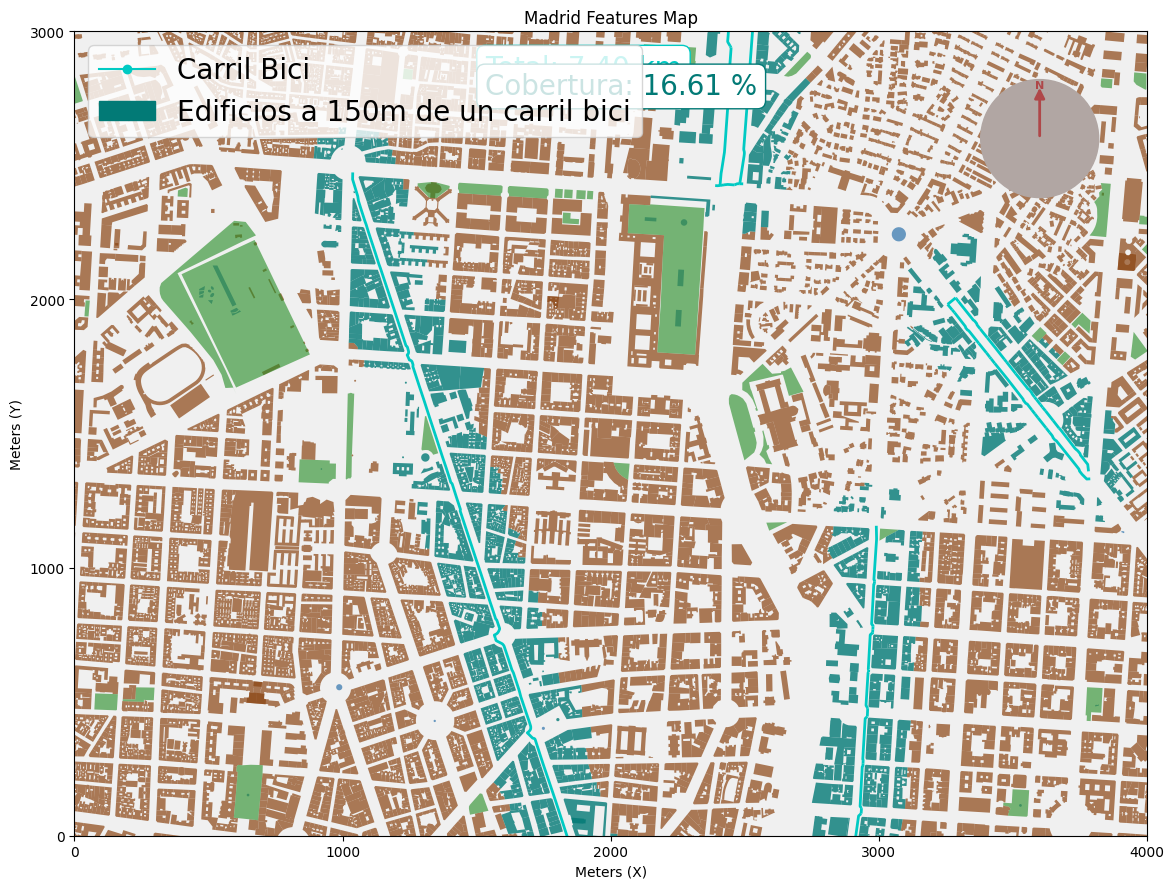


3. Rotated Features Map
------------------------------
🎨 Generating features map for city 1...
   Center: (40.440087, -3.695152)
   Boundary: 4000m x 3000m at 45° rotation
🔄 Loading features from database for city 1...
   ✔ buildings: 4750 features
   ✔ waterways: 25 features
   ✔ forest: 53 features
   ✔ bike_paths: 72 features
   ✔ land: 92 features
   ✔ bike_path_buildings: 1043 features


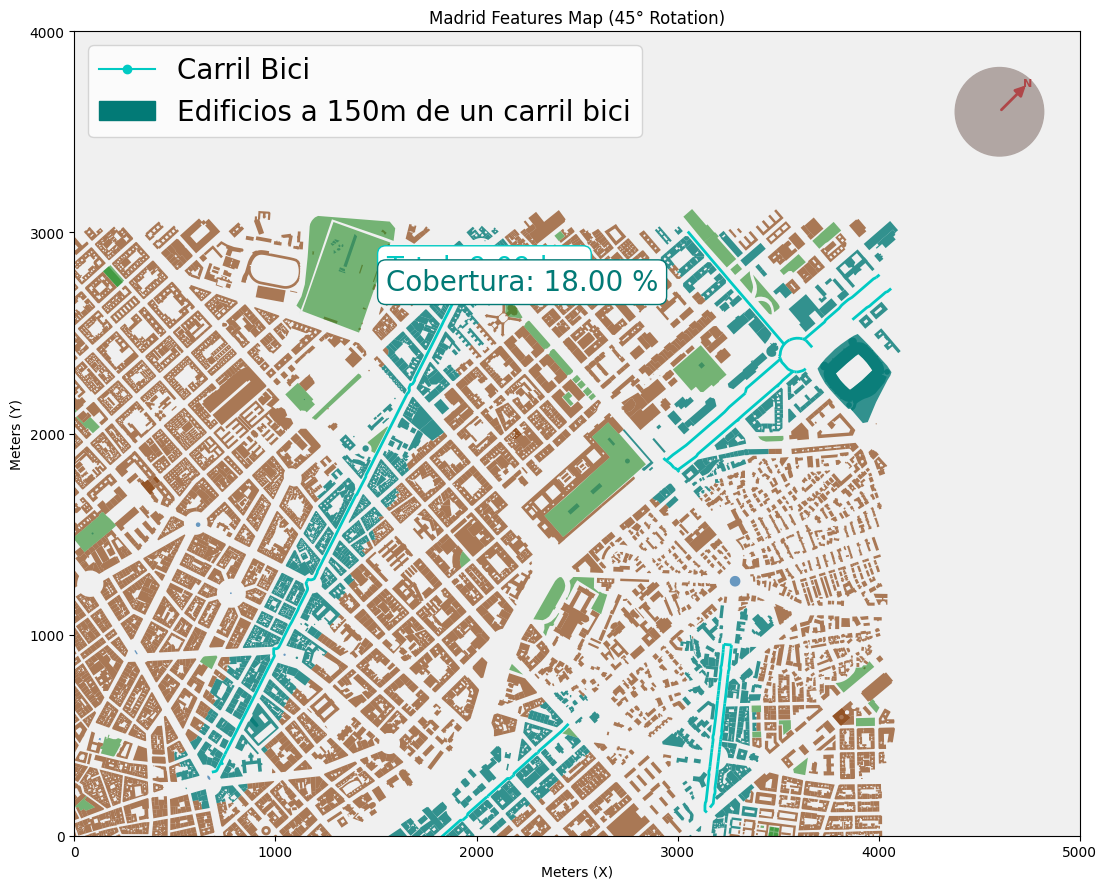


4. Focused Features Map
------------------------------
🎨 Generating features map for city 1...
   Center: (40.440087, -3.695152)
   Boundary: 20000m x 15000m at 0° rotation
🔄 Loading features from database for city 1...
   ✔ buildings: 76713 features
   ✔ forest: 1459 features
   ✔ waterways: 522 features
   ✔ bike_paths: 1168 features
   ✔ land: 3038 features
   ✔ bike_path_buildings: 10003 features


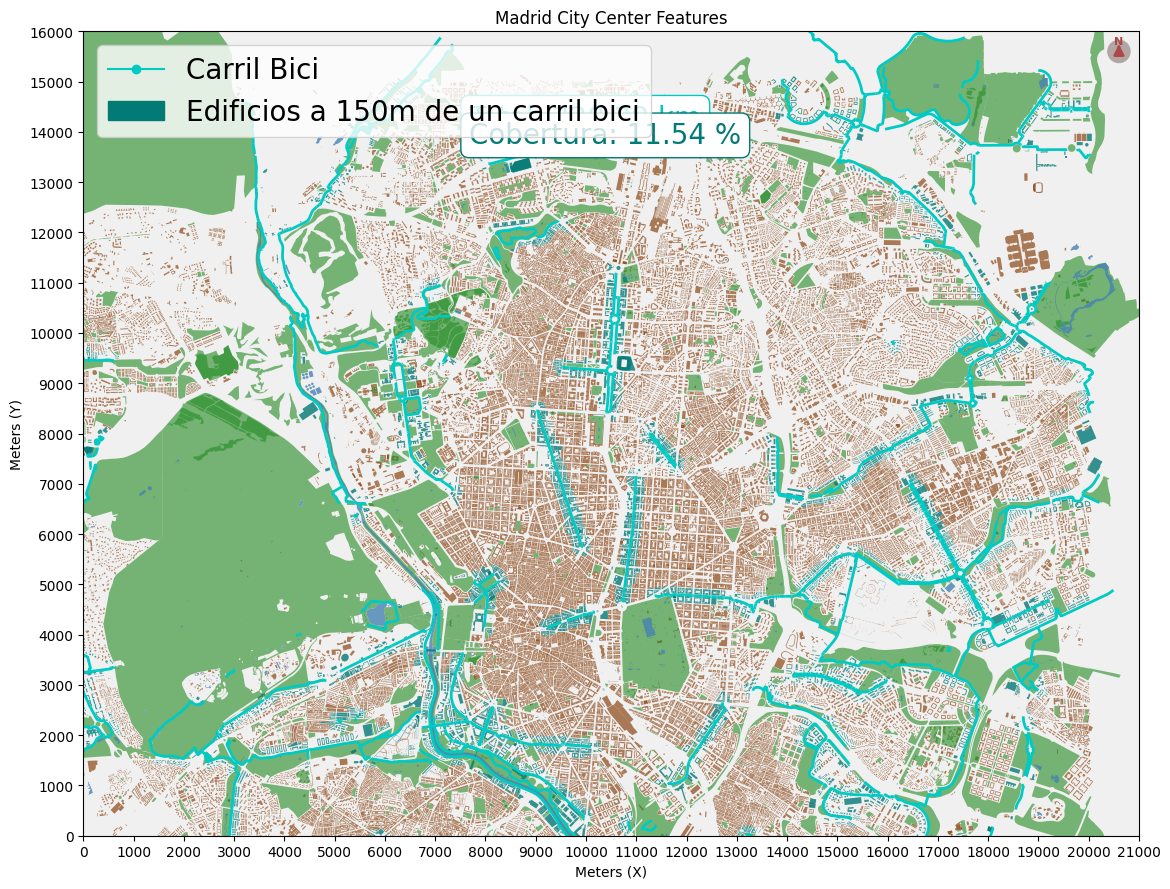


✅ All visualization tests completed!
📊 All plots displayed directly in notebook


In [10]:
# Feature Visualization Test - Notebook Cell Version
# Copy-paste this entire cell into your notebook

from backend.database.city_io import connect_db, get_city_center
from backend.processing.visualization import generate_features_map, plot_features_overview

# Connect to database
conn = connect_db()
city_id = 1  # Madrid city

print("🎨 Testing Feature Visualization System")
print("=" * 50)

# Test 1: Features overview
print("\n1. Features Overview Plot")
print("-" * 30)
plot_features_overview(conn, city_id)

# Get Madrid center
center_data = get_city_center(conn, city_id)
if center_data:
    center_lat, center_lon, radius = center_data
    print(f"   Using Madrid center: ({center_lat:.6f}, {center_lon:.6f})")
else:
    # Default Madrid center
    center_lat, center_lon = 40.4401, -3.6952
    print(f"   Using default Madrid center: ({center_lat:.6f}, {center_lon:.6f})")

# Feature configuration (colors, styles, etc.)
features_config = {
    'buildings': {
        'color': '#8B4513',  # Brown
        'alpha': 0.7,
        'linewidth': 0
    },
    'bike_path_buildings': {
        'color': '#027A76',  # Dark teal
        'alpha': 0.8,
        'linewidth': 0
    },
    'bike_paths': {
        'color': '#00cac3',  # Cyan
        'alpha': 1.0,
        'linewidth': 2
    },
    'waterways': {
        'color': '#4682B4',  # Steel blue
        'alpha': 0.8,
        'linewidth': 1
    },
    'forest': {
        'color': '#228B22',  # Forest green
        'alpha': 0.6,
        'linewidth': 0
    }
}

# Plot settings
settings = {
    'title': 'Madrid Features Map',
    'background': '#f0f0f0',  # Light gray
    'width': 4000,  # 4km width
    'height': 3000,  # 3km height
    'legend': {
        'bike_lanes': True,
        'coverage': True
    },
    'annotations': {
        'total_length': {
            'plot': True,
            'value': None  # Will be calculated
        },
        'coverage': {
            'plot': True,
            'value': None  # Will be calculated
        }
    }
}

# Test 2: Generate main features map
print("\n2. Main Features Map")
print("-" * 30)
generate_features_map(
    conn=conn,
    city_id=city_id,
    center_lat=center_lat,
    center_lon=center_lon,
    angle=0,  # No rotation
    width=4000,  # 4km
    height=3000,  # 3km
    features_config=features_config,
    settings=settings
)

# Test 3: Generate rotated map
print("\n3. Rotated Features Map")
print("-" * 30)
settings_rotated = settings.copy()
settings_rotated['title'] = 'Madrid Features Map (45° Rotation)'
generate_features_map(
    conn=conn,
    city_id=city_id,
    center_lat=center_lat,
    center_lon=center_lon,
    angle=45,  # 45 degree rotation
    width=4000,
    height=3000,
    features_config=features_config,
    settings=settings_rotated
)

# Test 4: Focus on smaller area
print("\n4. Focused Features Map")
print("-" * 30)
settings_focused = settings.copy()
settings_focused['title'] = 'Madrid City Center Features'
generate_features_map(
    conn=conn,
    city_id=city_id,
    center_lat=center_lat,
    center_lon=center_lon,
    angle=0,
    width=20000,  # 2km
    height=15000,  # 1.5km
    features_config=features_config,
    settings=settings_focused
)

conn.close()
print("\n✅ All visualization tests completed!")
print("📊 All plots displayed directly in notebook") 